# Grad-Shafranov equilibria: solver, PINN, surrogate, inverse

Axisymmetric tokamak equilibrium is the Grad-Shafranov problem. In cylindrical coordinates the poloidal flux $\psi(R, Z)$ satisfies

$$
\Delta^*\psi \equiv R\partial_R\negthinspace{}\left(\frac{1}{R}\partial_R\psi\right) + \partial_Z^2\psi = -\mu_0 R J_\phi,
$$

with $J_\phi$ set by the pressure and toroidal-field profiles, which themselves depend on $\psi$. The fixed-boundary problem takes the plasma shape and those profiles and returns $\psi$. The free-boundary problem, and equilibrium reconstruction, also have to place the boundary so that the external magnetic measurements are matched.

A nonlinear finite-difference solve is accurate and, on a $65\times 65$ mesh, only a few tens of milliseconds. Real-time shape control and between-shot reconstruction still want a map that is cheaper than a fresh solve, and a reconstruction map that goes straight from diagnostics to $\psi$. This notebook compares four approaches that share one set of conventions ($\psi = 0$ on the boundary, $\psi_\mathrm{axis} \gt 0$ for the solver family, arrays shaped `(nr, nz)` with `indexing="ij"`, SI units):

1. A second-order finite-difference solver, checked against a Cerfon–Freidberg Solov'ev equilibrium.
2. Physics-informed networks trained on the strong form, with no interior flux target.
3. Supervised surrogates (MLP–CNN and FNO) from the nine equilibrium parameters to $\psi(R, Z)$.
4. An inverse network from synthetic magnetic diagnostics to $\psi$, when that checkpoint is present.

No model is retrained here. Checkpoints under `outputs/` are loaded as they are.

In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath(".."))
os.chdir(os.path.abspath(".."))

import torch
torch.set_num_threads(2)

from IPython.display import Image, Markdown, display
from eval import compare


def show(result):
    if result is None:
        return
    if isinstance(result, str):
        display(Markdown(result))
        return
    table = result.get("table")
    if table:
        display(Markdown(table))
    paths = []
    for key in ("figure", "figure_samples", "figure_q"):
        if result.get(key):
            paths.append(result[key])
    for extra in result.get("figures") or []:
        if extra not in paths:
            paths.append(extra)
    for path in paths:
        display(Image(filename=path))


## Finite-difference verification

The Solov'ev equilibrium used here is the up-down symmetric Cerfon–Freidberg solution with $\epsilon = 0.32$, $\kappa = 1.7$, $\delta = 0.33$, $A = -0.155$, and $R_0 = 1\thinspace{}\mathrm{m}$. The analytic flux is negative inside the plasma. The finite-difference code solves $\Delta^*\psi =$ that analytic right-hand side with $\psi = 0$ on the curved boundary (Shortley–Weller cuts). On a smooth solution the truncation error is $O(h^2)$, so the relative L2 should fall with slope 2 on a log-log plot against the mesh spacing.

solver verification: n=33 relL2=1.362e-04, n=65 relL2=3.059e-05, n=129 relL2=6.822e-06


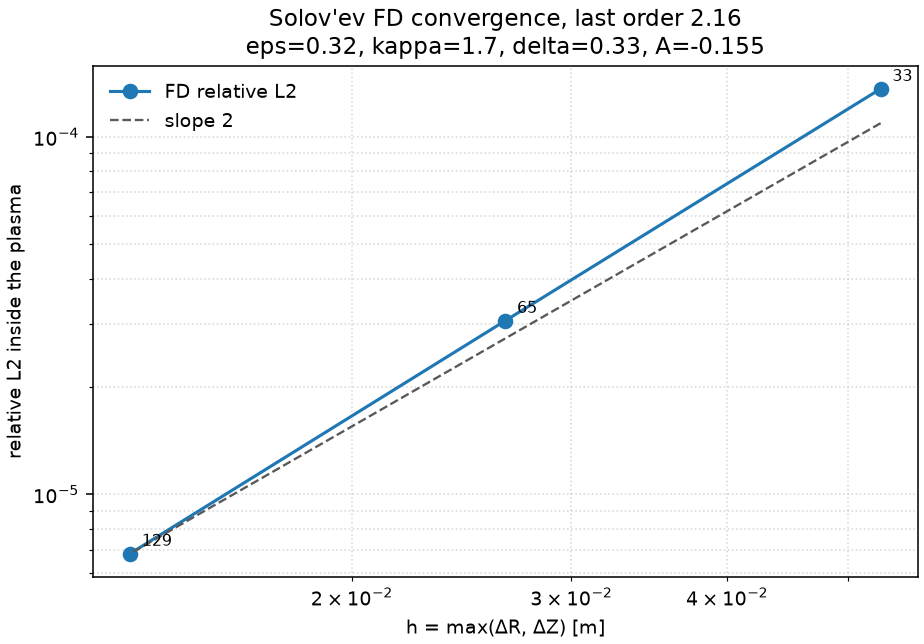

n=  33  rel L2=1.361859e-04  order=None
n=  65  rel L2=3.058574e-05  order=2.154646308363523
n= 129  rel L2=6.821821e-06  order=2.164630429133481


In [2]:
solver = compare.solver_verification()
show(solver)
for n, err, order in zip(solver["n"], solver["rel_l2"], solver["observed_order"]):
    print(f"n={n:4d}  rel L2={err:.6e}  order={order}")


## Physics-informed networks

Each PINN is an MLP on affinely scaled $(R, Z)$. The Solov'ev network matches $\Delta^*\psi$ to the analytic right-hand side. The nonlinear network uses a lagged (Picard) current profile with the same shape and profiles as the finite-difference benchmark. The parametric network adds the Solov'ev parameter $A$ as a conditioning input and is scored on values of $A$ it did not train on.

The figure overlays interior flux surfaces (solid: reference, dashed: network) and the pointwise error. Relative L2 numbers printed from the checkpoint were computed on this same $129\times 129$ box.

PINN: solovev relL2=3.146e-04, nonlinear relL2=8.482e-03, parametric relL2=1.941e-03


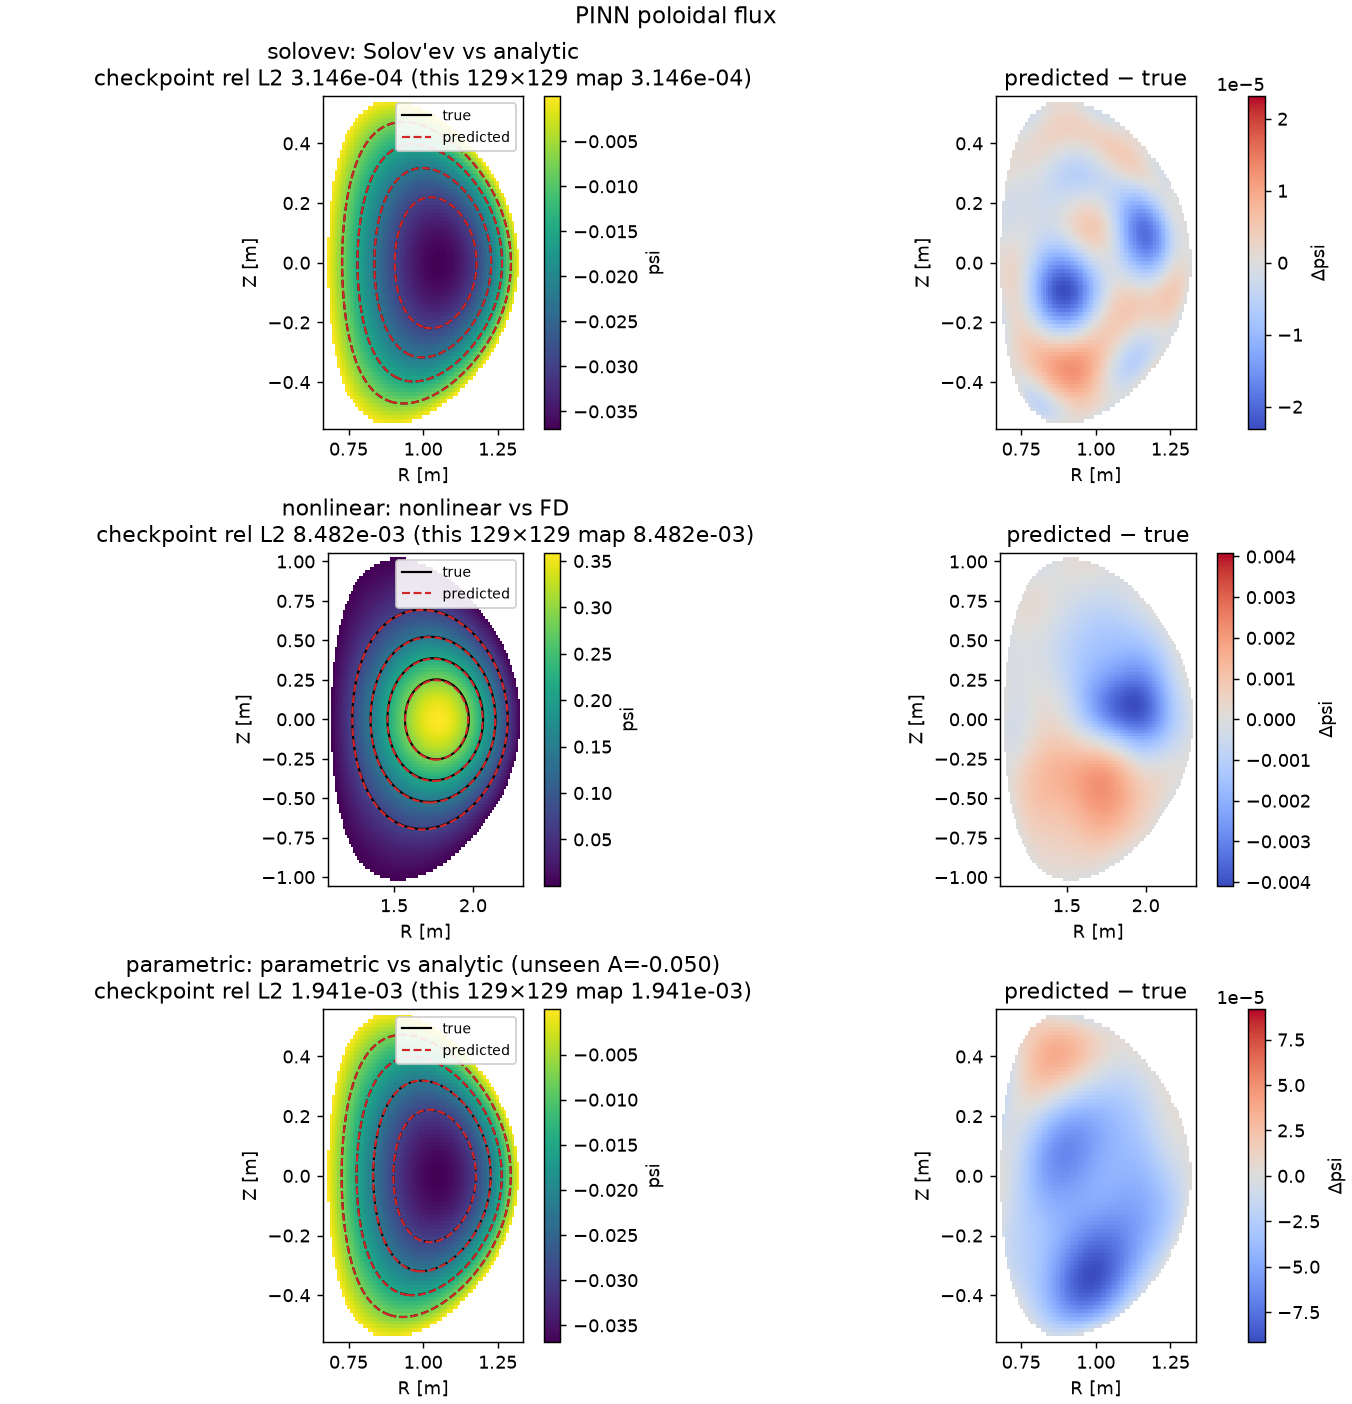

checkpoint rel L2 {'solovev': 0.0003146189671040387, 'nonlinear': 0.008481723320609131, 'parametric': 0.0019413589678302272}
axis error [m] {'solovev': 4.6837041604509035e-05, 'parametric': 0.00033761495583034025, 'nonlinear': 0.0050313623362955315}


In [3]:
pinn = compare.pinn_summary()
show(pinn)
print("checkpoint rel L2", {k: pinn["metrics"][k]["rel_l2"] for k in pinn["metrics"]})
print("axis error [m]", pinn["checkpoint_axis_error_m"])


## Supervised surrogates

The surrogates are trained on 4000 fixed-boundary equilibria (validation 500, test 500) that share one $65\times 65$ grid. Inputs are $(R_0, a, \kappa, \delta, I_p, \beta_0, \alpha, \gamma, B_0)$. Two architectures, an MLP–CNN and a Fourier neural operator, are each trained with physics weight 0 and 0.1. The physics term penalizes $\Delta^*\psi_\mathrm{pred} + \mu_0 R J_\mathrm{true}$ on interior plasma nodes. The out-of-distribution file keeps every range the same except elongation, which sits in $(2.0, 2.3]$.

The sample figure is the best run by mean test relative L2. Flux surfaces of the stored solution and of the prediction are overlaid; the second column is the error inside the known boundary. The safety-factor comparison uses three test equilibria. $F(\psi_n) = R B_\phi$ comes from a fresh `solve_fixed_boundary` of that equilibrium (the true $F$), and $q$ is the contour integral in `eval.metrics.q_profile` on both the stored $\psi$ and the predicted $\psi$, for $\psi_n$ from 0.05 to 0.95.

surrogate: best=mlpcnn_pw0p1 by test relative L2


| run | test rel L2 | OOD rel L2 | test GS residual | OOD GS residual | test axis error [m] | OOD axis error [m] | test q95 rel | OOD q95 rel |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| mlpcnn_pw0 | 1.4165e-02 | 2.1474e-02 | 9.7724e-01 | 1.2284e+00 | 8.356e-03 | 2.235e-02 | 1.356e-01 | 8.442e-02 |
| mlpcnn_pw0p1 | 1.0868e-02 | 1.8626e-02 | 3.2714e-02 | 5.3227e-02 | 1.397e-03 | 2.300e-03 | 2.427e-02 | 4.639e-02 |
| fno_pw0 | 2.4592e-02 | 3.8916e-02 | 5.6419e-01 | 6.0688e-01 | 5.765e-03 | 7.389e-03 | 2.596e-01 | 2.394e-01 |
| fno_pw0p1 | 2.1135e-02 | 3.6404e-02 | 5.1008e-02 | 8.5946e-02 | 3.388e-03 | 6.074e-03 | 2.736e-01 | 2.856e-01 |



| run | test rel L2 | OOD rel L2 | test GS residual | OOD GS residual | test axis error [m] | OOD axis error [m] | test q95 rel | OOD q95 rel |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| mlpcnn_pw0 | 1.4165e-02 | 2.1474e-02 | 9.7724e-01 | 1.2284e+00 | 8.356e-03 | 2.235e-02 | 1.356e-01 | 8.442e-02 |
| mlpcnn_pw0p1 | 1.0868e-02 | 1.8626e-02 | 3.2714e-02 | 5.3227e-02 | 1.397e-03 | 2.300e-03 | 2.427e-02 | 4.639e-02 |
| fno_pw0 | 2.4592e-02 | 3.8916e-02 | 5.6419e-01 | 6.0688e-01 | 5.765e-03 | 7.389e-03 | 2.596e-01 | 2.394e-01 |
| fno_pw0p1 | 2.1135e-02 | 3.6404e-02 | 5.1008e-02 | 8.5946e-02 | 3.388e-03 | 6.074e-03 | 2.736e-01 | 2.856e-01 |


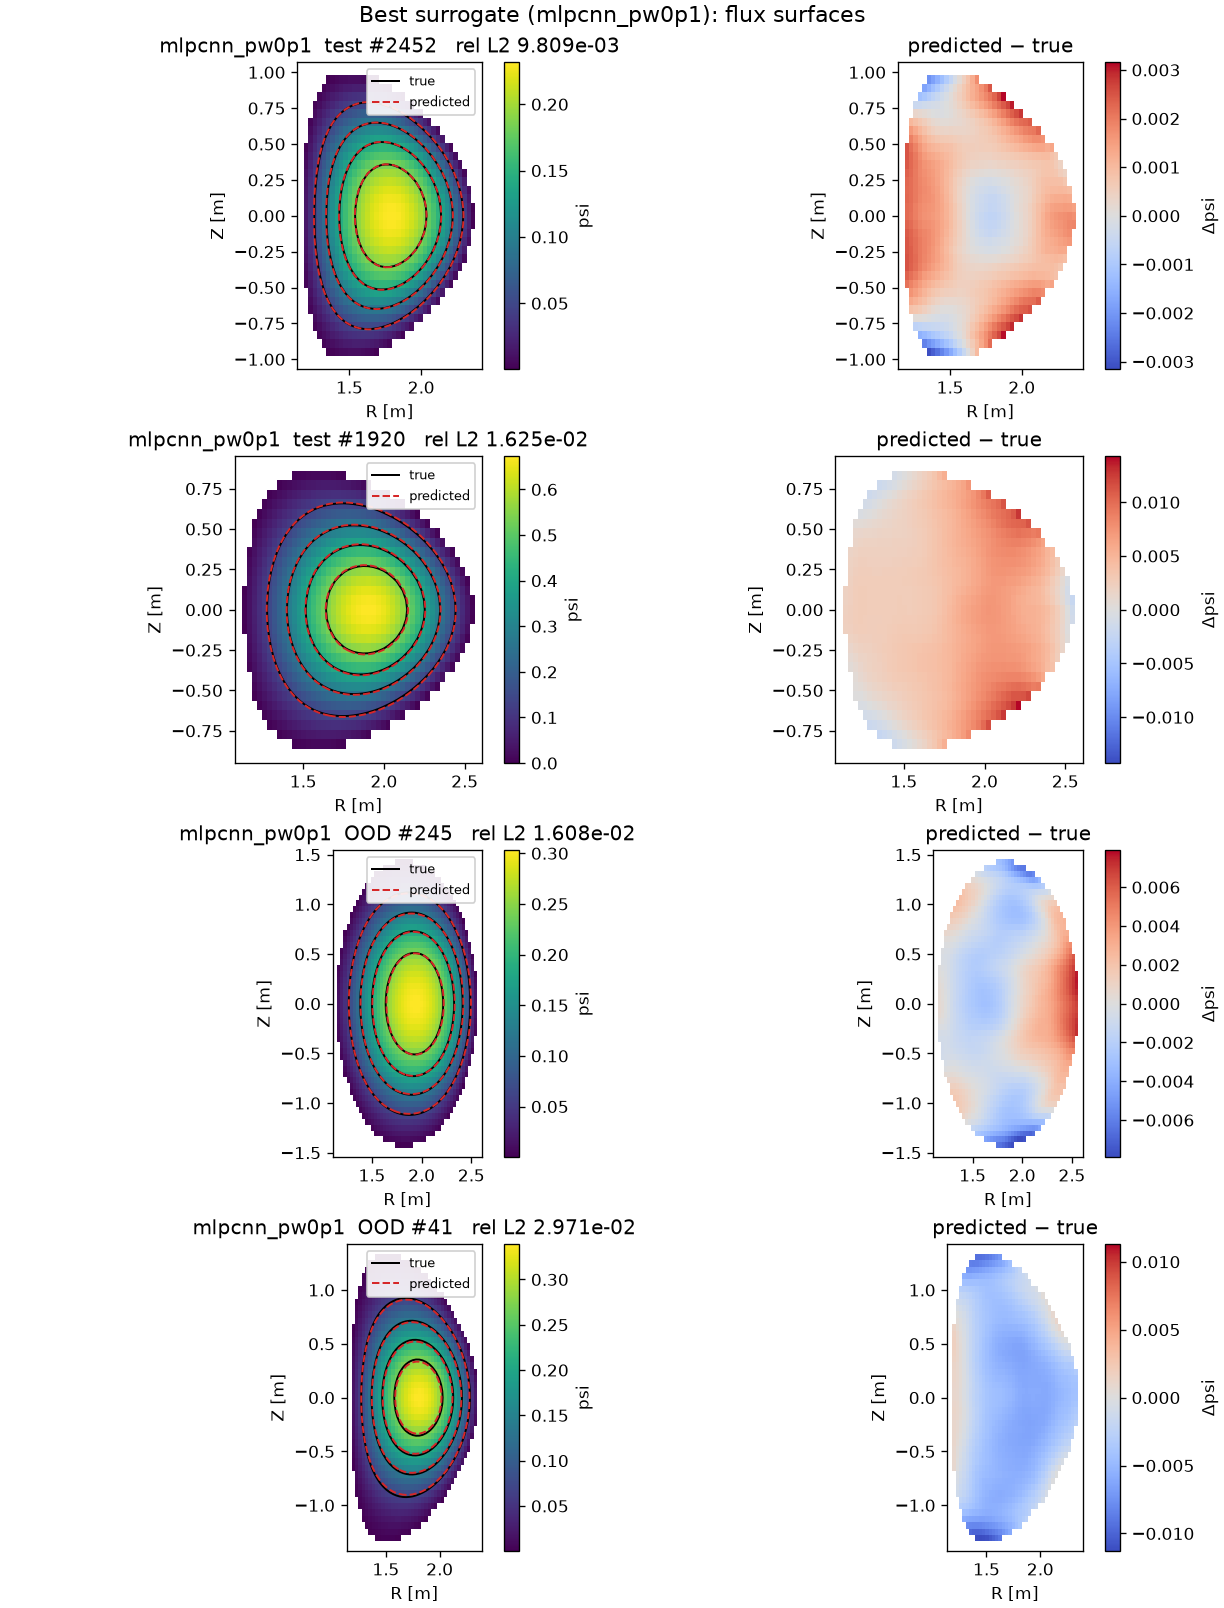

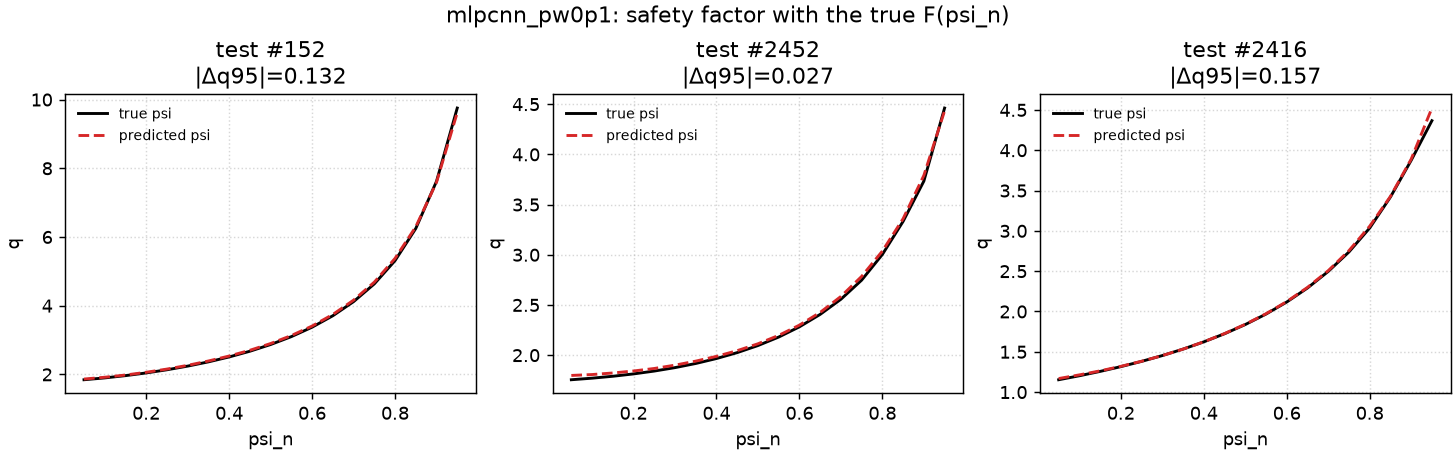

best: mlpcnn_pw0p1
test #152: rel L2=8.1179e-03  q95 true=9.754 pred=9.621
test #2452: rel L2=9.8089e-03  q95 true=4.462 pred=4.434
test #2416: rel L2=1.2781e-02  q95 true=4.367 pred=4.523


In [4]:
surrogate = compare.surrogate_summary()
show(surrogate)
print("best:", surrogate["best"])
for sample in surrogate["q_samples"]:
    print(
        f"test #{sample['dataset_index']}: rel L2={sample['rel_l2']:.4e}  "
        f"q95 true={sample['q95_true']:.3f} pred={sample['q95_pred']:.3f}"
    )


## Speed

Times are medians from `eval.metrics.time_call` (one untimed warm-up, then five calls). The finite-difference entry is one nonlinear fixed-boundary solve on the $65\times 65$ benchmark. Each PINN entry is a forward pass on that same grid. Surrogate entries are a single sample of each trained network, plus a batch of the 500 test equilibria for the best network. Inverse timing is one `reconstruct` call when that checkpoint exists.

| call | median time |
| --- | --- |
| FD nonlinear solve, 65×65 | 44.32 ms |
| PINN solovev inference, 65×65 | 2.06 ms |
| PINN nonlinear inference, 65×65 | 2.05 ms |
| PINN parametric inference, 65×65 | 2.07 ms |
| surrogate mlpcnn_pw0, 1 sample | 1.09 ms |
| surrogate mlpcnn_pw0p1, 1 sample | 1.05 ms |
| surrogate fno_pw0, 1 sample | 2.89 ms |
| surrogate fno_pw0p1, 1 sample | 2.84 ms |
| surrogate mlpcnn_pw0p1, batch of 500 | 273.42 ms |
| surrogate mlpcnn_pw0p1, per sample in a batch of 500 | 0.55 ms |
| inverse reconstruct, 1 sample | 1.20 ms |
| inverse FreeGS reconstruct, 1 sample | 1.20 ms |



| call | median time |
| --- | --- |
| FD nonlinear solve, 65×65 | 44.32 ms |
| PINN solovev inference, 65×65 | 2.06 ms |
| PINN nonlinear inference, 65×65 | 2.05 ms |
| PINN parametric inference, 65×65 | 2.07 ms |
| surrogate mlpcnn_pw0, 1 sample | 1.09 ms |
| surrogate mlpcnn_pw0p1, 1 sample | 1.05 ms |
| surrogate fno_pw0, 1 sample | 2.89 ms |
| surrogate fno_pw0p1, 1 sample | 2.84 ms |
| surrogate mlpcnn_pw0p1, batch of 500 | 273.42 ms |
| surrogate mlpcnn_pw0p1, per sample in a batch of 500 | 0.55 ms |
| inverse reconstruct, 1 sample | 1.20 ms |
| inverse FreeGS reconstruct, 1 sample | 1.20 ms |


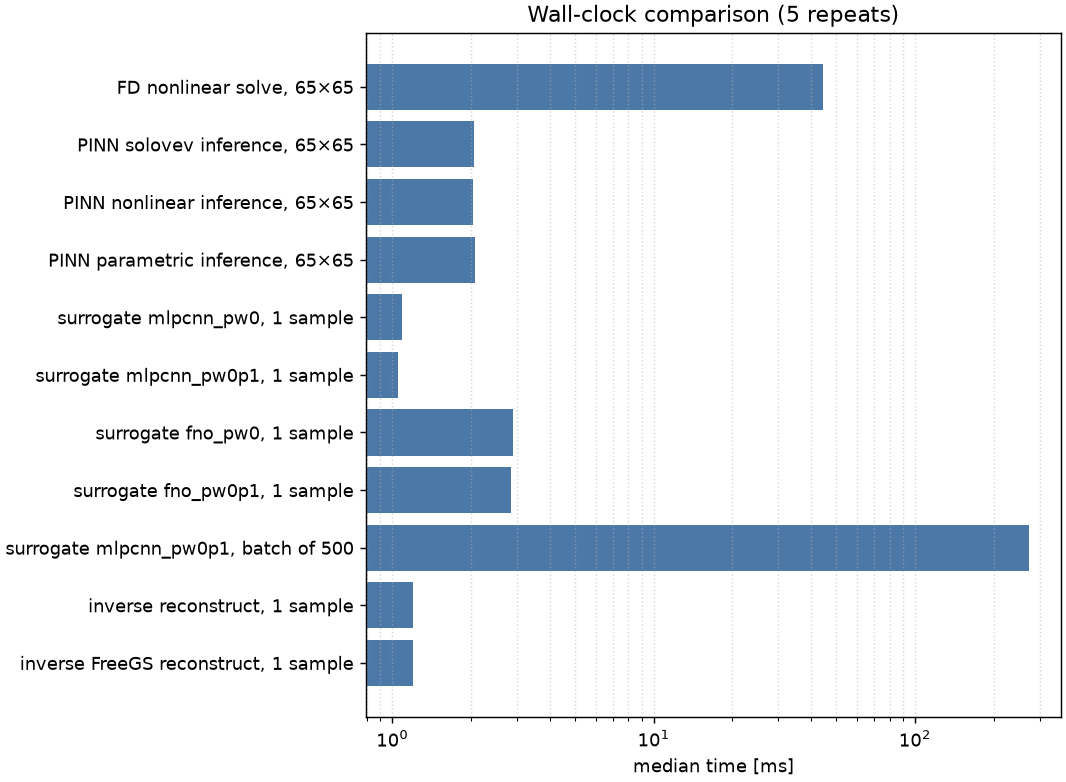

In [5]:
speed = compare.speed_table()
show(speed)


## Inverse reconstruction

The inverse model maps synthetic pickup-probe, flux-loop, and Rogowski signals to $\psi$. It is optional in this report: if the package or the checkpoint is missing, the cell prints `inverse model not available` and continues. When the checkpoint is present the curves below are read from the metrics JSON (no new sensor sweep and no retraining), and one `reconstruct` call is timed in the speed section. Training noise is 1% of each channel's RMS. A second head was trained on the 298-sample FreeGS TestTokamak set when that file was available.

The selected network is a direct decoder: it predicts the normalized flux shape and a scale, with sensor features normalized by $I_p$. External magnetics determine some equilibrium parameters and leave others free. The cell below prints `param_r2_clean` and the variant table from the metrics file. The pattern is that $I_p$ and $R_0$ are fixed by the measurements, while $\beta_0$, $\alpha$, and $\gamma$ are only weakly constrained, and $B_0$ does not enter $\psi$. A hybrid that predicts the nine parameters and then evaluates the frozen surrogate — accurate when those parameters are the true ones — reaches the same flux error as the direct model. That shared floor is missing information. A production EFIT fit adds internal constraints (MSE, pressure, and kinetic profiles) that this diagnostic set does not have.

inverse: test relL2=0.1707, axis=6.0626e-03 m, lcfs=0.06558914725504957, q95 abs=1.4027150060187046


### Identifiability

External magnetics fix the plasma current and the major radius, and they barely constrain the current profile. On clean signals, R^2 is 1.00 for Ip and 0.96 for R0, against 0.00 for beta0, 0.22 for alpha, and 0.41 for gamma. The boundary parameters sit in between (a 0.43, kappa 0.51, delta 0.58). B0 has R^2 -0.03: it does not enter psi, and these poloidal diagnostics do not measure it. Given the true parameters, the best surrogate (`mlpcnn_pw0p1`) has test relative L2 0.0109 (about 1.1%). A hybrid that maps the sensors to the nine equilibrium parameters and then through the frozen surrogate has test relative L2 0.1696. The direct network, sensors to psi, reaches 0.1707 in distribution and 0.1894 on the high-elongation set (LCFS error 0.0656 m, absolute q95 error 1.403). The hybrid and the direct decoder land on the same flux error, so that floor is the part of the equilibrium the external measurements do not determine, rather than a failure to fit the network. A pr

### Identifiability

External magnetics fix the plasma current and the major radius, and they barely constrain the current profile. On clean signals, R^2 is 1.00 for Ip and 0.96 for R0, against 0.00 for beta0, 0.22 for alpha, and 0.41 for gamma. The boundary parameters sit in between (a 0.43, kappa 0.51, delta 0.58). B0 has R^2 -0.03: it does not enter psi, and these poloidal diagnostics do not measure it. Given the true parameters, the best surrogate (`mlpcnn_pw0p1`) has test relative L2 0.0109 (about 1.1%). A hybrid that maps the sensors to the nine equilibrium parameters and then through the frozen surrogate has test relative L2 0.1696. The direct network, sensors to psi, reaches 0.1707 in distribution and 0.1894 on the high-elongation set (LCFS error 0.0656 m, absolute q95 error 1.403). The hybrid and the direct decoder land on the same flux error, so that floor is the part of the equilibrium the external measurements do not determine, rather than a failure to fit the network. A production EFIT reconstruction adds internal constraints (MSE, pressure, and kinetic profiles) that this sensor set does not include.

### Per-parameter R^2 (`param_r2_clean`)

| parameter | R^2 |
| --- | --- |
| Ip | 0.999 |
| R0 | 0.961 |
| a | 0.434 |
| kappa | 0.515 |
| delta | 0.578 |
| beta0 | 0.002 |
| alpha | 0.219 |
| gamma | 0.407 |
| B0 | -0.026 |

### Architecture variants

| variant | arch | epochs | test rel L2 | OOD rel L2 | axis error [m] | q95 abs | note |
| --- | --- | --- | --- | --- | --- | --- | --- |
| direct_v1_global_scale | direct | 30 | 0.1751 | 0.1906 | 0.0059 | 3.034 | Previous run: global psi RMS, small bilinear decoder. Val loss flat at 0.059 by epoch 26. |
| hybrid_surrogate | hybrid | 55 | 0.1696 | — | — | — | Sensors to 9 params, frozen mlpcnn surrogate. Clean-signal test L2. Param R^2: Ip 1.00, R0 0.96, a 0.44, kappa 0.52, delta 0.61, gamma 0.41, alpha 0.21, beta0 ~0, B0 ~0. |
| direct_shape_8ep | direct | 8 | 0.1757 | — | — | — | Shape times exp(log psi_axis), before Ip-normalized features. |
| direct_shape_ip_16ep | direct | 16 | 0.1734 | — | — | — | Shape decoder plus Ip-normalized sensor features. Still descending at epoch 16. |
| direct_shape_ip_48ep | direct | 48 | 0.1707 | 0.1894 | 0.0061 | 1.403 | Selected default. Train rel L2 0.169, val 0.175 (no overfit). |


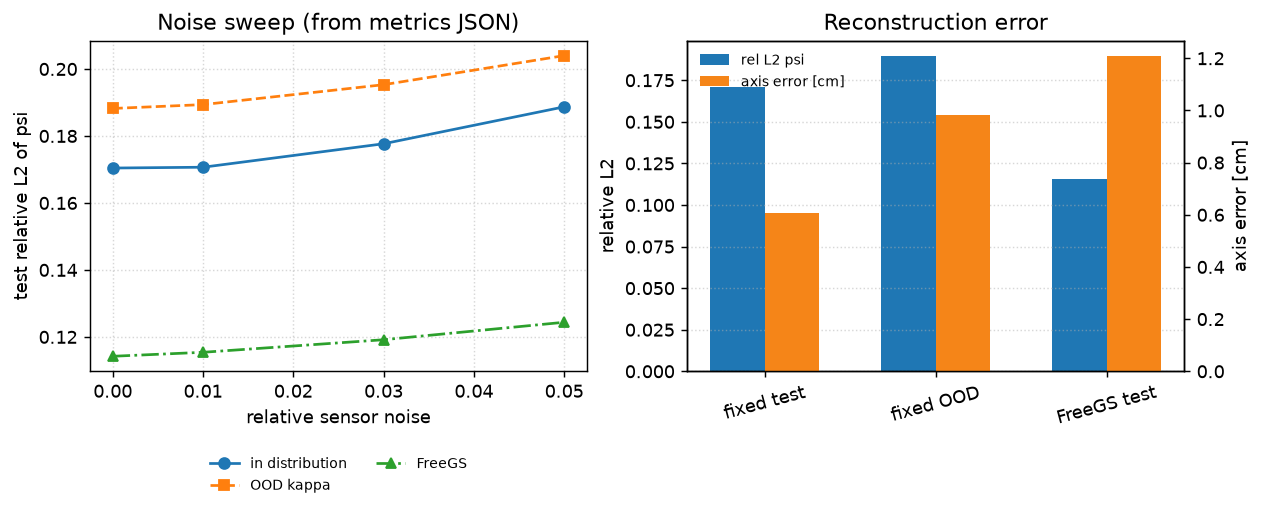

In [6]:
inverse = compare.inverse_summary()
show(inverse)


## Summary

One row per model. Relative L2, axis error, and $q_{95}$ error are taken from the checkpoint metrics. Inference times are the measurements from the speed section. Empty cells are quantities that the corresponding metrics file does not record.

In [7]:
table = compare.overall_table()
show(table)


| model | task | input | rel L2 psi | axis error | q95 error | inference time |
| --- | --- | --- | --- | --- | --- | --- |
| fd-solovev | FD verification vs analytic Solov'ev | boundary + GS right-hand side | 3.0586e-05 | — | — | — |
| fd-nonlinear-65 | nonlinear fixed-boundary solve | shape + profiles, 65×65 | reference | — | — | 44.32 ms |
| pinn-solovev | PINN, one Solov'ev equilibrium | (R, Z) | 3.1462e-04 | 4.684e-05 m | — | 2.06 ms |
| pinn-nonlinear | PINN, one nonlinear equilibrium | (R, Z) | 8.4817e-03 | 5.031e-03 m | — | 2.05 ms |
| pinn-parametric | PINN conditioned on A | (R, Z, A) | 1.5538e-03 mean (max 1.9414e-03) | 3.376e-04 m | — | 2.07 ms |
| mlpcnn_pw0 | surrogate, parameters → psi | R0, a, kappa, delta, Ip, beta0, alpha, gamma, B0 | 1.4165e-02 (OOD 2.1474e-02) | 8.356e-03 m (OOD 2.235e-02 m) | 1.356e-01 rel (OOD 8.442e-02 rel) | 1.09 ms |
| mlpcnn_pw0p1 | surrogate, parameters → psi (best) | R0, a, kappa, delta, Ip, beta0, alpha, gamma, B0 | 1.0868e-02 (OOD 1.8626e-02) | 1.397e-03 m (OOD 2.300e-03 m) | 2.427e-02 rel (OOD 4.639e-02 rel) | 1.05 ms |
| fno_pw0 | surrogate, parameters → psi | R0, a, kappa, delta, Ip, beta0, alpha, gamma, B0 | 2.4592e-02 (OOD 3.8916e-02) | 5.765e-03 m (OOD 7.389e-03 m) | 2.596e-01 rel (OOD 2.394e-01 rel) | 2.89 ms |
| fno_pw0p1 | surrogate, parameters → psi | R0, a, kappa, delta, Ip, beta0, alpha, gamma, B0 | 2.1135e-02 (OOD 3.6404e-02) | 3.388e-03 m (OOD 6.074e-03 m) | 2.736e-01 rel (OOD 2.856e-01 rel) | 2.84 ms |
| inverse-fixed | inverse, magnetics → psi (1% noise) | 101 magnetic signals | 1.7067e-01 (OOD 1.8937e-01) | 6.063e-03 m | 1.403e+00 abs | 1.20 ms |
| inverse-freegs | inverse, FreeGS magnetics + coils (1% noise) | magnetic signals + PF coil currents | 1.1541e-01 | 1.207e-02 m | — | 1.20 ms |

Notes:

- Relative L2 for the PINNs is the checkpoint value on the 129×129 evaluation grid, inside the plasma. The parametric row quotes the mean over the four unseen values of A, with the worst value in parentheses. Its axis error is the mean magnetic-axis error over those same four values.
- The Solov'ev finite-difference row is the relative L2 against the analytic flux on the 65×65 mesh (eps=0.32, kappa=1.7, delta=0.33, A=-0.155). It is a discretization error, not a learned-model error.
- Surrogate numbers are means on the fixed-boundary test split (500 equilibria); OOD is kappa in (2.0, 2.3]. q95 error is relative, |q_pred − q_true| / |q_true| at psi_n = 0.95, using the true F.
- Inverse q95 error is absolute (the metrics JSON does not store a relative q95). The fixed-boundary inverse was trained at 1% sensor noise.
- Inference times are median wall-clock times from `eval.metrics.time_call` (one warm-up, then the recorded repeats) with `torch.set_num_threads(2)`. PINN times are one 65×65 grid. Surrogate times are one sample. The nonlinear solve is the 65×65 benchmark equilibrium.
- Batched surrogate throughput (mlpcnn_pw0p1-batch500): 273.42 ms for 500 samples (0.55 ms per sample).
